<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula04d%20-%20Single%20Hidden%20Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

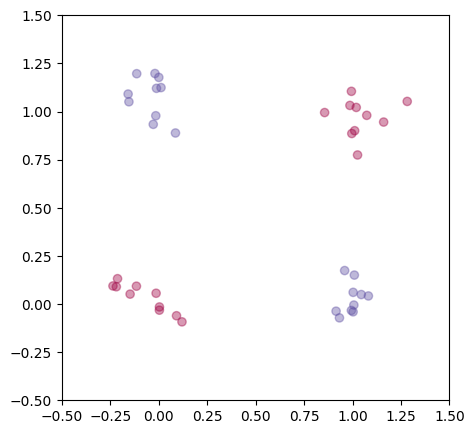

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)

def plotHyperplan(vector, intercept=0):
  xs = np.array([-0.5,1.5])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, '-')

def makeLogicalDataset(n=40, func=lambda a, b: bool(a) != bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0,0],[1,0],[1,1],[0,1]],
                    cluster_std=0.1)
  y = np.array([func(a>0.5, b>0.5) for a, b, in zip(X[:,0], X[:,1])], dtype=int) * 2 - 1
  return X, y

X, y = makeLogicalDataset()
plotDataset(X, y)
plt.show()

In [139]:
def defineAxes(X):
  offset = 0.5
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)


Accuracy: 1.0


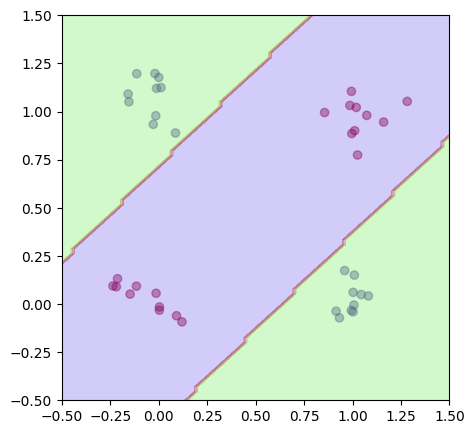

In [152]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class LastLayer(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=1000, learning_rate=0.001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.n_hidden = 2
    self.activ_func = np.tanh

  def forward(self, X):
    Xb = include_bias(X)
    self.pH = Xb @ self.ihw
    self.H = self.activ_func(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    return logits

  def backward(self, y, logits):
    error = logits - y
    self.how -= self.Hb.T @ error * self.learning_rate
    pass

  def fit(self, X, y):
    self.ihw = np.array([[0.5, -1, 1], [0.5, 1, -1]]).T
    if len(y.shape) == 1:
      y = y.reshape(-1, 1)
    self.how = np.random.uniform(-1, 1, (self.ihw.shape[1]+1, y.shape[1]))
    for _ in range(self.max_iter):
      logits = self.forward(X)
      self.backward(y, logits)
    return self

  def predict(self, X):
    logits = self.forward(X)
    ypred = sign(logits)
    return ypred

model = LastLayer()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


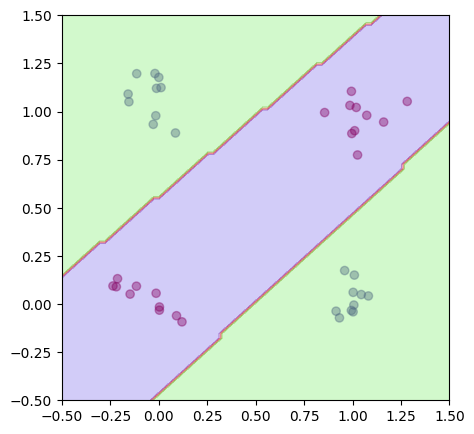

In [171]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class SingleHiddenLayer(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=10000, learning_rate=0.01):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.n_hidden = 2
    self.activ_func = np.tanh

  def forward(self, X):
    self.Xb = include_bias(X)
    self.pH = self.Xb @ self.ihw
    self.H = self.activ_func(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    return logits

  def backward(self, y, logits):
    ho_delta = logits - y
    ho_grad = self.Hb.T @ ho_delta
    ### PULO DO GATO ###
    tanh_grad = 1 - self.H**2
    ih_delta = ho_delta @ self.how[1:].T * tanh_grad
    ### #### ## #### ###
    ih_grad = self.Xb.T @ ih_delta
    self.ihw -= ih_grad * self.learning_rate
    self.how -= ho_grad * self.learning_rate
    pass

  def fit(self, X, y):
    if len(y.shape) == 1:
      y = y.reshape(-1, 1)
    self.ihw = np.random.uniform(-1, 1, (X.shape[1]+1, self.n_hidden))
    self.how = np.random.uniform(-1, 1, (self.ihw.shape[1]+1, y.shape[1]))
    for _ in range(self.max_iter):
      logits = self.forward(X)
      self.backward(y, logits)
    return self

  def predict(self, X):
    logits = self.forward(X)
    ypred = sign(logits)
    return ypred

model = SingleHiddenLayer()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()